In [1]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['NanumGothic']


# 선 그래프와 그래프 완성

In [2]:
import matplotlib.pyplot as plt

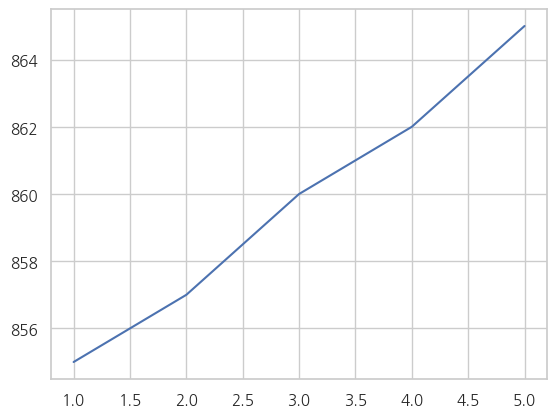

In [3]:
# 간단한 선 그래프 만들기
x = [ 1, 2, 3, 4, 5]
y = [ 855, 857, 860, 862, 865]
plt.plot(x, y)
plt.show() # colab에는 안써줘도 그래프가 나오지만, show()를 생활화하는 습관을 들입시다!

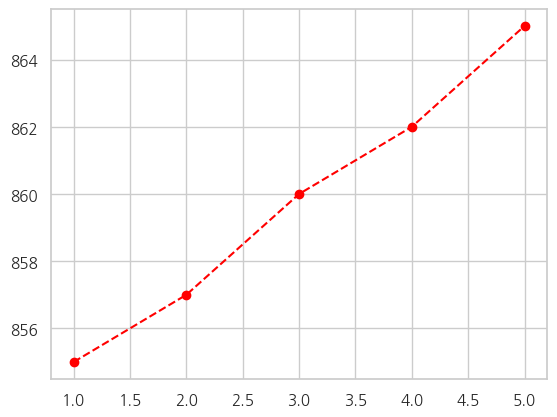

In [4]:
# 위 그래프를 꾸며봅시다
plt.plot(x, y, color = 'red', linestyle = '--', marker = 'o')
plt.show()

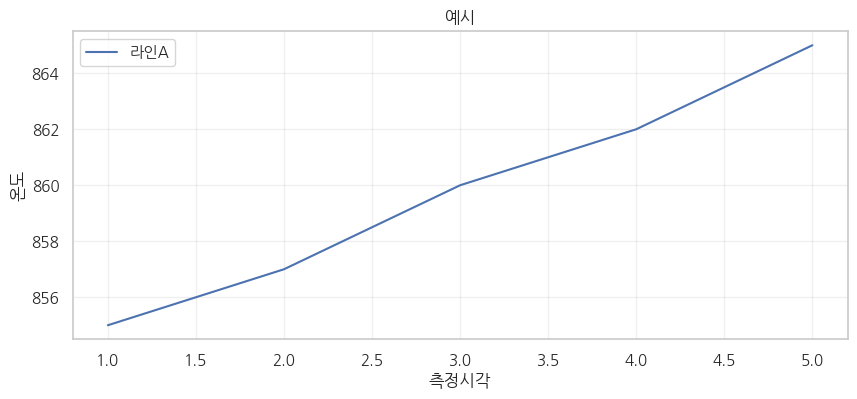

In [5]:
# 제목·축
plt.figure(figsize = (10, 4))
plt.plot(x, y, label = '라인A')
plt.legend(loc = "upper left")
# +--------------+--------------+---------------+
# | 'upper left' |'upper center'| 'upper right' |
# +--------------+--------------+---------------+
# |'center left' |   'center'   |'center right' |
# +--------------+--------------+---------------+
# | 'lower left' |'lower center'| 'lower right' |
# +--------------+--------------+---------------+
plt.grid(True, alpha = 0.3) # alpha 투명도
plt.title('예시')
plt.xlabel('측정시각') # x축 범례
plt.ylabel('온도') # y축 범례
plt.show()

## 실습 1. 환경 준비와 첫 그래프
한글 폰트 설정 후 리스트로 첫 선 그래프 출력

목표
- 한글 폰트를 설정하고 리스트로 첫 선 그래프 출력

단계
- pyplot을 plt 별칭으로 불러오기
- rcParams로 한글 폰트를 설정해 글자 깨짐 방지
- 요일·온도 리스트를 plot으로 그리고 화면에 표시

예상 결과
- 오른쪽 위로 상승하는 선 그래프 한 장

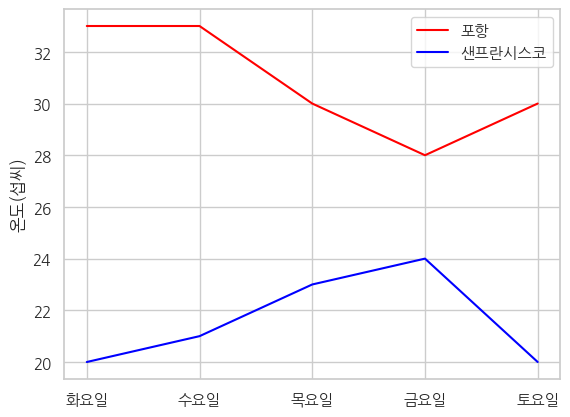

In [6]:
# 요일
days = ["화요일", "수요일", "목요일", "금요일", "토요일"]

# 온도
weathers_pohang = [33, 33, 30, 28, 30]
weathers_sf = [20, 21, 23, 24, 20]

plt.plot(days, weathers_pohang, label = '포항', color = 'red')
plt.plot(days, weathers_sf, label = '샌프란시스코', color = 'blue')
plt.legend(loc = "upper right")
plt.ylabel('온도(섭씨)')
plt.show()

## 실습 2. 선 그래프 직접 그리기
색·선 스타일·마커를 바꿔 가며 선 그래프 그리기

목표
- 색·선 스타일·마커를 바꿔 가며 선 그래프 그리기

단계
- 설비 데이터를 불러와 A호기 행만 고르기
- 일자와 온도로 기본 선 그래프 그리기
- color·linestyle·marker로 선을 꾸며 다시 그리기

예상 결과
- 기본→색→점선·마커 순으로 바뀌는 선 그래프

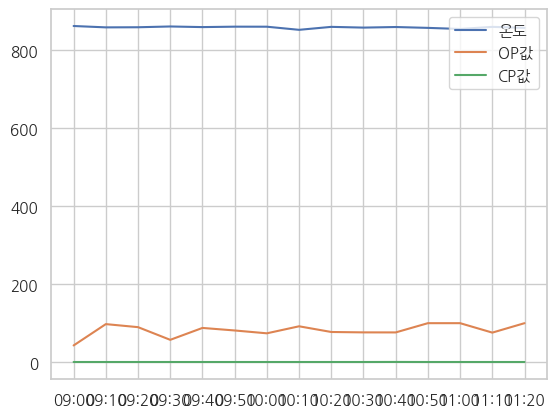

In [8]:
df = pd.read_csv('17_열처리.csv')

df_a = df[df['배치'] == '로트A']

plt.plot(df_a['측정시각'], df_a['온도'], label = '온도')
plt.plot(df_a['측정시각'], df_a['OP값'], label = 'OP값')
plt.plot(df_a['측정시각'], df_a['CP값'], label = 'CP값')
plt.legend(loc = "upper right")
plt.show()

# 아래 결과처럼 온도, OP값, CP값의 단위를
# 동일하게 놓고 보는게 옳은지 늘 고민해야한다!

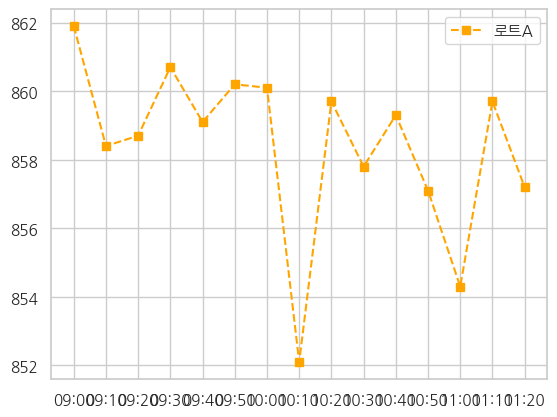

In [9]:
df_a = df[df['배치'] == '로트A']

plt.plot(df_a['측정시각'], df_a['온도'], label = '로트A', color = 'orange', linestyle = '--', marker = 's')
plt.legend(loc = "upper right")
plt.show()

## 실습 3. 센서값 추세 선 그래프
실데이터로 한 설비 추세와 두 설비 비교 그리기

목표
- 실데이터로 한 설비 추세와 두 설비 비교 그리기

단계
- C호기 행을 골라 마커를 붙인 온도 추세 그리기
- A호기와 C호기를 겹쳐 그리고 각 선에 이름표 달기
- legend로 범례를 표시해 어느 선이 어느 설비인지 구분

예상 결과
- C호기 추세와 A·C호기 비교 그래프(범례 포함)

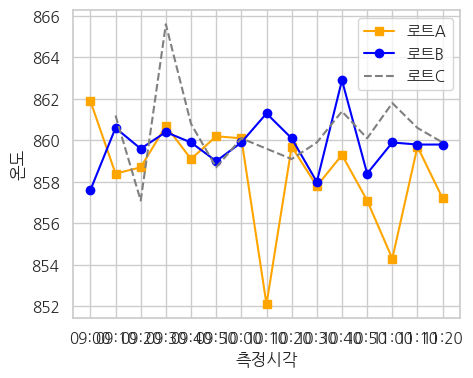

In [10]:
df_a = df[df['배치'] == '로트A']
df_b = df[df['배치'] == '로트B']
df_c = df[df['배치'] == '로트C']

plt.figure(figsize=(5, 4)) # 전체 그래프의 크기
plt.plot(df_a['측정시각'], df_a['온도'], label = '로트A', color = 'orange', marker = 's')
plt.plot(df_b['측정시각'], df_b['온도'], label = '로트B', color = 'blue', marker = 'o')
plt.plot(df_c['측정시각'], df_c['온도'], label = '로트C', color = 'gray', linestyle = '--')
plt.legend(loc = "upper right")
plt.ylabel('온도')
plt.xlabel('측정시각')

plt.savefig('sample.png')
plt.show()
# 이렇게 로트별로 같은 온도계열을 같은 시간대별로 보여주기는 가능하다!

## 실습 4. 제목·축·범례 갖춘 완성형 그래프

제목·축 이름·범례를 모두 갖춘 읽히는 그래프 완성

단계
- figsize로 가로로 긴 그래프 틀 만들기(plot보다 먼저)
- 두 설비를 색·마커를 달리해 겹쳐 그리기
_ 제목·가로축·세로축 이름과 범례 위치를 지정

예상 결과
- 제목·축이름·범례를 갖춘 두 설비 비교 그래프

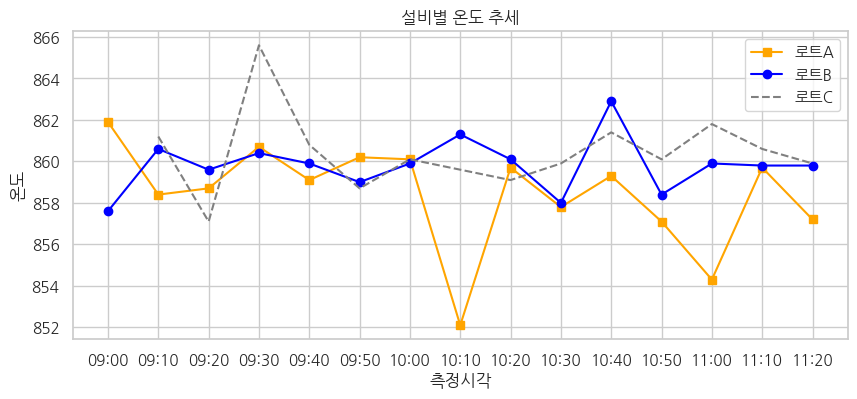

In [11]:
df_a = df[df['배치'] == '로트A']
df_b = df[df['배치'] == '로트B']
df_c = df[df['배치'] == '로트C']

plt.figure(figsize=(10, 4)) # 전체 그래프의 크기
plt.title('설비별 온도 추세')
plt.plot(df_a['측정시각'], df_a['온도'], label = '로트A', color = 'orange', marker = 's')
plt.plot(df_b['측정시각'], df_b['온도'], label = '로트B', color = 'blue', marker = 'o')
plt.plot(df_c['측정시각'], df_c['온도'], label = '로트C', color = 'gray', linestyle = '--')
plt.legend(loc = "upper right")
plt.ylabel('온도')
plt.xlabel('측정시각')

plt.savefig('sample.png')
plt.show()
# 이렇게 로트별로 같은 온도계열을 같은 시간대별로 보여주기는 가능하다!

## 실습 5. 다중 센서 비교 그래프와 저장
반복문으로 세 설비를 비교하고 이미지로 저장

단계
- 설비 이름과 색 목록을 반복하며 각 설비 온도 선 그리기
- 제목·축 이름·범례로 그래프를 완성
- savefig로 그래프를 이미지 파일로 저장(show보다 먼저)

예상 결과
- 세 설비 온도 비교 그래프가 파일로 저장

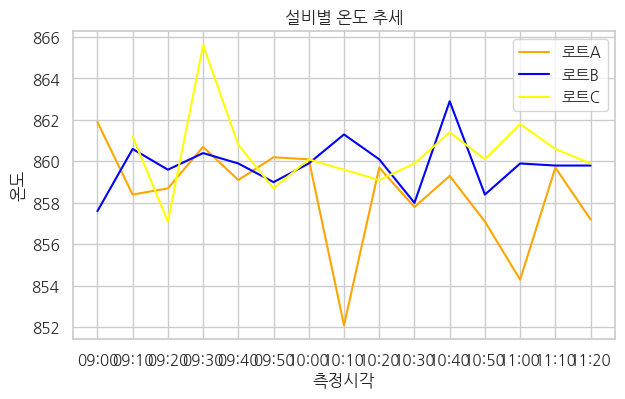

In [15]:
plt.figure(figsize=(7, 4)) # 전체 그래프의 크기
plt.title('설비별 온도 추세')

names = [ ('로트A', 'orange'),
          ('로트B', 'blue'),
          ('로트C', 'yellow')]

for (name, color) in names:
  df_name = df[df['배치'] == name]
  plt.plot(df_name['측정시각'], df_name['온도'], label = name, color = color)

plt.legend(loc = "upper right")
plt.ylabel('온도')
plt.xlabel('측정시각')

plt.savefig('sample.png')
plt.show()

## 실습 6. 선 그래프 자유 변형
- 한 설비의 여러 센서를 한 그래프에 종합
- 한 설비의 여러 센서를 한 그래프에 종합해 그리기

단계
- C호기의 온도·진동·소음을 한 그래프에 겹쳐 그리기
- 단위가 다른 진동은 배수를 곱해 눈에 보이게 보정
- 제목·축 이름·범례로 완성하고 함께 움직이는지 관찰

예상 결과
- C호기 온도·진동·소음이 함께 상승하는 종합 그래프

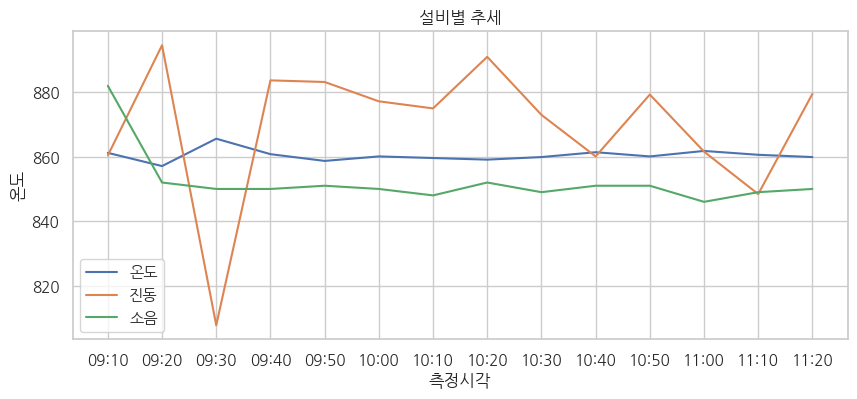

In [27]:
plt.figure(figsize=(10, 4)) # 전체 그래프의 크기
plt.title('설비별 추세')

plt.plot(df_c['측정시각'], df_c['온도'], label = '온도')
plt.plot(df_c['측정시각'], df_c['OP값'] + 800, label = '진동') # 진동
plt.plot(df_c['측정시각'], df_c['CP값'] * 1000 + 400, label = '소음') # 소음

plt.legend()

plt.ylabel('온도')
plt.xlabel('측정시각')

plt.savefig('sample.png')

plt.show()
